In [1]:
# Test GPU Access on Compute Node
import torch
import socket

print(f"Hostname: {socket.gethostname()}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
else:
    print("No CUDA GPUs available")

Hostname: ggpu133
CUDA available: True
GPU count: 1
Current GPU: 0
GPU 0: NVIDIA A100-SXM4-40GB
  Memory: 39.5 GB


In [2]:
import sys
# sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/analysis/src")
import os
import pickle
import matplotlib
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm
import typing as t
import argparse
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass

from v1t.utils import utils, tensorboard
from v1t import losses, data
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler

from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

utils.set_random_seed(1234)

tensorboard.set_font()

# Evaluate a chosen model

In [3]:
import gc
# This function serves to clear GPU memory (VRAM)
def clear_gpu_memory(restart_like=True):
    """
    Reliably clears ALL PyTorch GPU memory.
    """
    # Step 1: Explicitly delete common objects (customize as needed)
    for obj in ['model', 'processor', 'optimizer', 'inputs', 'predictions']:
        if obj in globals():
            globals().__delitem__(obj)
    
    # Step 2: Force Python garbage collection
    gc.collect()
    
    # Step 3: Synchronize CUDA operations
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        
        # Step 4: Nuclear option - reset CUDA state (PyTorch 2.0+)
        if restart_like:
            torch.cuda.reset_peak_memory_stats()
            # Note: full reset requires process restart
    
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.1f} GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.1f} GB")

clear_gpu_memory()

GPU memory allocated: 0.0 GB
GPU memory reserved:  0.0 GB


In [4]:
@torch.no_grad()
def compute_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):
    """Metrics to compute as part of training and validation step"""
    msse = losses.msse(y_true=y_true, y_pred=y_pred)
    poisson_loss = losses.poisson_loss(y_true=y_true, y_pred=y_pred)
    correlation = losses.correlation(y1=y_pred, y2=y_true, dim=0)
    correlation = torch.mean(correlation)
    bits_per_spike = losses.bits_per_spike(y_true=y_true, y_pred=y_pred)
    return {
        "metrics/msse": msse,
        "metrics/poisson_loss": poisson_loss,
        "metrics/single_trial_correlation": correlation,
        "metrics/bits_per_spike": bits_per_spike,
    }

def evaluate_model(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    scaler: GradScaler,
    verbose: bool = True,
):
    model.to(device).eval()
    results = {}
    for mouse_id, ds in ds.items():
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        print(f"Fraction of input neurons: {frac_input_neurons}")
        N = ds.dataset.num_neurons
        print(f"N neurons: {N}")
        
        all_results = []  # Store results from each iteration

        if frac_input_neurons == 0.:
            targets, predictions = [], [] 
            for batch in tqdm(ds, desc=f"Mouse {mouse_id}", disable=not verbose):
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=None,
                            query_neuron_ids=torch.arange(N).to(device),
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                    targets.append(y_true.detach().cpu())
                    predictions.append(y_pred.detach().cpu())
                    del y_true, y_pred
                        
            targets = torch.vstack(targets).cpu()
            predictions = torch.vstack(predictions).cpu()
            
            # Compute metrics for this iteration
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions)
            
            del targets, predictions
            torch.cuda.empty_cache()

        else:
            rep = 10
            for i in range(rep):  # repeat evaluation n times with different input/query split
                perm = torch.randperm(N, device=device)
                K = int(frac_input_neurons * N)
                input_neuron_ids = perm[:K].to(device)
                print(f"Iteration {i+1}: Using {len(input_neuron_ids)} input neurons.")
                query_neuron_ids = perm[K:].to(device)
                targets, predictions = [], [] 
                
                for batch in tqdm(ds, desc=f"Mouse {mouse_id} - Iter {i+1}/{rep}", disable=not verbose):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                                images=batch["image"].to(device),
                                responses=batch["response"].to(device),
                                neuron_coords=batch["neuron_coordinates"].to(device),
                                input_neuron_ids=input_neuron_ids,
                                query_neuron_ids=query_neuron_ids,
                                mouse_id=mouse_id,
                                behaviors=batch["behavior"].to(device),
                                pupil_centers=batch["pupil_center"].to(device),
                            )
                        targets.append(y_true.detach().cpu())
                        predictions.append(y_pred.detach().cpu())
                        del y_true, y_pred
                        
                targets = torch.vstack(targets).cpu()
                predictions = torch.vstack(predictions).cpu()
                
                # Compute metrics for this iteration
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions)
                # print(iteration_results)
                all_results.append(iteration_results)
                
                del targets, predictions

            # Aggregate results across all iterations
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key].item() if hasattr(result[key], 'item') else result[key] 
                        for result in all_results]
                v = np.asarray(values, float)
                n_nan = int(np.isnan(v).sum())
                mouse_results[f"{key}_mean"] = np.nanmean(v) if n_nan < v.size else np.nan
                mouse_results[f"{key}_std"]  = np.nanstd(v)  if n_nan < v.size else np.nan
                if n_nan>0:
                    print(n_nan, "nan values found")
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results

        torch.cuda.empty_cache()

    return results

In [5]:
def evaluate_model_sel_frac(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    sel_frac: float,
    scaler: GradScaler,
    verbose: bool = True,
):
    model.to(device).eval()
    results = {}
    for mouse_id, ds in ds.items():
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        print(f"Fraction of input neurons at train: {frac_input_neurons}")
        N = ds.dataset.num_neurons
        print(f"N neurons: {N}")
        
        all_results = []  # Store results from each iteration
        print(f"input fraction at test time: {sel_frac}")
        if sel_frac == 0.:
            targets, predictions = [], [] 
            for batch in tqdm(ds, desc=f"Mouse {mouse_id}", disable=not verbose):
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=None,
                            query_neuron_ids=torch.arange(N).to(device),
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                    targets.append(y_true.detach().cpu())
                    predictions.append(y_pred.detach().cpu())
                    del y_true, y_pred
                        
            targets = torch.vstack(targets).cpu()
            predictions = torch.vstack(predictions).cpu()
            
            # Compute metrics for this iteration
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions.to(torch.float32))
            
            del targets, predictions
            torch.cuda.empty_cache()

        else:
            rep = 10
            for i in range(rep):  # repeat evaluation n times with different input/query split
                perm = torch.randperm(N, device=device)
                K = int(sel_frac * N)
                input_neuron_ids = perm[:K].to(device)
                print(f"Iteration {i+1}: Using {len(input_neuron_ids)} input neurons.")
                query_neuron_ids = perm[K:].to(device)
                targets, predictions = [], [] 
                
                for batch in tqdm(ds, desc=f"Mouse {mouse_id} - Iter {i+1}/{rep}", disable=not verbose):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                                images=batch["image"].to(device),
                                responses=batch["response"].to(device),
                                neuron_coords=batch["neuron_coordinates"].to(device),
                                input_neuron_ids=input_neuron_ids,
                                query_neuron_ids=query_neuron_ids,
                                mouse_id=mouse_id,
                                behaviors=batch["behavior"].to(device),
                                pupil_centers=batch["pupil_center"].to(device),
                            )
                        targets.append(y_true.detach().cpu())
                        predictions.append(y_pred.detach().cpu())
                        del y_true, y_pred
                        
                targets = torch.vstack(targets).cpu()
                predictions = torch.vstack(predictions).cpu()

                # Compute metrics for this iteration
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions.to(torch.float32))
                all_results.append(iteration_results)
                
                del targets, predictions

            # Aggregate results across all iterations
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key].item() if hasattr(result[key], 'item') else result[key] 
                        for result in all_results]
                mouse_results[f"{key}_mean"] = np.mean(values)
                mouse_results[f"{key}_std"] = np.std(values)
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results

        torch.cuda.empty_cache()

    return results

In [6]:
def evaluate_over_fractions(K, ALPHA, FRAC_INPUT_MODEL, SEED, LR="04", val=False):
    STC_means = {}
    STC_std = {}
    for frac in FRAC_INPUT_MODEL:
        # load model
        out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_{frac}_s_{SEED}"
        parser = argparse.ArgumentParser()
        parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium")
        parser.add_argument("--output_dir", type=str, required=True)
        parser.add_argument("--batch_size", type=int, default=10)
        parser.add_argument("--device", type=str, default="cuda")

        args = parser.parse_args([
            "--output_dir", f"{out_dir}",
        ])
        if not os.path.isdir(args.output_dir):
            raise FileNotFoundError(f"Cannot find {args.output_dir}.")

        utils.get_device(args)
        utils.set_random_seed(1234)

        utils.load_args(args)

        train_ds, val_ds, test_ds = data.get_training_ds(
            args,
            data_dir=args.dataset,
            mouse_ids=args.mouse_ids,
            batch_size=args.batch_size,
            device=args.device,
        )

        model = Model(args, ds=val_ds) if val else Model(args, ds=test_ds)
        model.eval()

        scheduler = Scheduler(args, model=model, save_optimizer=False)
        scheduler.restore(force=True)
        scaler = GradScaler(enabled=args.amp)

        # evaluate 
        mouse_results = evaluate_model(
            ds=val_ds if val else test_ds,
            model=model,
            device=args.device,
            scaler=scaler,
            verbose=True,
        )
        clear_gpu_memory()
        # torch.empty_cache()
        if frac == "00":
            STC_means[frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation']
            STC_std[frac] = 0.0
        else:
            STC_means[frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_mean']
            STC_std[frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_std']

    return STC_means, STC_std

In [7]:
def evaluate_over_sel_fractions(sel_frac, K, ALPHA, FRAC_INPUT_MODEL, SEED, LR="04", val=False):
    STC_means = {}
    STC_std = {}
    for s_frac in sel_frac:
        # load model
        out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"
        parser = argparse.ArgumentParser()
        parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium")
        parser.add_argument("--output_dir", type=str, required=True)
        parser.add_argument("--batch_size", type=int, default=10)
        parser.add_argument("--device", type=str, default="cuda")

        args = parser.parse_args([
            "--output_dir", f"{out_dir}",
        ])
        if not os.path.isdir(args.output_dir):
            raise FileNotFoundError(f"Cannot find {args.output_dir}.")

        utils.get_device(args)
        utils.set_random_seed(1234)

        utils.load_args(args)

        train_ds, val_ds, test_ds = data.get_training_ds(
            args,
            data_dir=args.dataset,
            mouse_ids=args.mouse_ids,
            batch_size=args.batch_size,
            device=args.device,
        )

        model = Model(args, ds=val_ds) if val else Model(args, ds=test_ds)
        model.eval()

        scheduler = Scheduler(args, model=model, save_optimizer=False)
        scheduler.restore(force=True)
        scaler = GradScaler(enabled=args.amp)

        # evaluate 
        mouse_results = evaluate_model_sel_frac(
            ds=val_ds if val else test_ds,
            model=model,
            device=args.device,
            sel_frac = s_frac,
            scaler=scaler,
            verbose=True,
        )
        clear_gpu_memory()
        # torch.empty_cache()
        if s_frac == 0.0:
            STC_means[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation']
            STC_std[s_frac] = 0.0
        else:
            STC_means[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_mean']
            STC_std[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_std']

    return STC_means, STC_std

In [8]:
def _parse_frac_key(k: str) -> float:
    k = str(k).strip()
    if "." in k:
        return float(k)
    if "_" in k:
        return float(k.replace("_", "."))
    if k.isdigit():
        if len(k) == 2:      # "00".."99"  -> percent
            return int(k) / 100.0
        if len(k) == 3:      # "000".."999" -> permille
            return int(k) / 1000.0
        # fallback: already a decimal-ish integer, assume it's percent if big
        v = int(k)
        return v / 100.0 if v > 1 else float(v)
    raise ValueError(f"Unrecognized frac key: {k}")

In [9]:
K=8
ALPHA="max"
frac=["00", "001", "01", "02", "03", "05", "10", "20", "50"]#["00", "02", "05", "10", "20", "50"]#["10", "20", "50"]##["00", "001", "02", "05", "10", "20", "50"]["00", "001", "02", "05", "10", "20"]
SEED=1
val=False
LR="004"

In [10]:
stc_means, stc_std = evaluate_over_fractions(K=K, ALPHA=ALPHA, FRAC_INPUT_MODEL=frac, SEED=SEED, LR=LR, val=val)

/mnt/vast-nhr/home/azhar.akhmetova/u12008/neuro-transformer/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_loc

image shape (1, 144, 256)
num_output_neurons {'k_8_a_max_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 11 (correlation: 0.0083).

Fraction of input neurons: 0.0
N neurons: 7334


Mouse k_8_a_max_b1e7_poisson: 100%|██████████| 498/498 [00:15<00:00, 33.07it/s]


GPU memory allocated: 0.0 GB
GPU memory reserved:  0.0 GB
image shape (1, 144, 256)
num_output_neurons {'k_8_a_max_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 240 (correlation: 0.4214).

Fraction of input neurons: 0.001
N neurons: 7334
Iteration 1: Using 7 input neurons.


Mouse k_8_a_max_b1e7_poisson - Iter 1/10: 100%|██████████| 498/498 [00:06<00:00, 80.26it/s]


...

Iteration 9: Using 3667 input neurons.


Mouse k_8_a_max_b1e7_poisson - Iter 9/10: 100%|██████████| 498/498 [00:09<00:00, 49.81it/s]


Iteration 10: Using 3667 input neurons.


Mouse k_8_a_max_b1e7_poisson - Iter 10/10: 100%|██████████| 498/498 [00:10<00:00, 49.01it/s]


10 nan values found
10 nan values found
GPU memory allocated: 0.0 GB
GPU memory reserved:  0.0 GB


In [11]:
stc_means, stc_std

({'00': tensor(-0.0039),
  '001': np.float64(0.38076252639293673),
  '01': np.float64(0.4015677273273468),
  '02': np.float64(0.9172145009040833),
  '03': np.float64(0.8792710423469543),
  '05': np.float64(0.7880309820175171),
  '10': np.float64(0.9811405122280121),
  '20': np.float64(0.9658958077430725),
  '50': np.float64(0.9743457019329071)},
 {'00': 0.0,
  '001': np.float64(0.041778898413248916),
  '01': np.float64(0.0043646967772232054),
  '02': np.float64(0.0025310989972699596),
  '03': np.float64(0.004319887997849276),
  '05': np.float64(0.003895949456805277),
  '10': np.float64(0.0002461220972607345),
  '20': np.float64(0.0007781515418983886),
  '50': np.float64(0.0003132323237758852)})

In [12]:
out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}"
import pandas as pd
fracs = np.array([_parse_frac_key(k) for k in stc_means.keys()], dtype=float)
print(fracs[0])
rows = []
i=0
for k, m in stc_means.items():
    rows.append({"frac": fracs[i], "mean": float(m), "std": float(stc_std[k])})
    i+=1
df = pd.DataFrame(rows).sort_values("frac")
filename = "stc_val_summary.csv" if val else "stc_test_summary.csv"
df.to_csv(os.path.join(out_dir, filename), index=False)

0.0


In [23]:
# -----------------------------------
#  add new rows for new runs per seed
# -----------------------------------
filename = "stc_val_summary.csv" if val else "stc_test_summary.csv"
csv_path = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/{filename}"
fracs = np.array([_parse_frac_key(k) for k in stc_means.keys()], dtype=float)
print(fracs[0])

new = pd.DataFrame([{"frac": fracs[i], "mean": m, "std": stc_std[k]} for i, (k, m) in enumerate(stc_means.items())])
new.head()

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df = pd.concat([df, new], ignore_index=True)
else:
    df = new

df = df.astype({"frac": float, "mean": float, "std": float}).sort_values("frac")
df.to_csv(csv_path, index=False)

0.0


In [50]:
K=16
ALPHA="1_2"
# FRAC_INPUT_MODEL="50"
SEED=1
val=False

In [51]:
for frac in ["01"]:
    sel_frac = [0., 0.001, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    STC_means, STC_std = evaluate_over_sel_fractions(sel_frac, K=K, ALPHA=ALPHA, FRAC_INPUT_MODEL=frac, SEED=SEED, val=val)
    out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{frac}_s_{SEED}"
    fracs = np.array([k for k in STC_means.keys()], dtype=float)
    print(fracs[0])
    rows = []
    i=0
    for k, m in STC_means.items():
        rows.append({"frac": fracs[i], "mean": float(m), "std": float(STC_std[k])})
        i+=1
    df = pd.DataFrame(rows).sort_values("frac")
    filename = "stc_val_per_model_summary.csv" if val else "stc_test_per_model_summary.csv"
    df.to_csv(os.path.join(out_dir, filename), index=False)

image shape (1, 144, 256)
num_output_neurons {'k_16_a_1_2_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 16 (correlation: 0.2091).

Fraction of input neurons at train: 0.01
N neurons: 7334
input fraction at test time: 0.0


Mouse k_16_a_1_2_b1e7_poisson: 100%|██████████| 498/498 [00:06<00:00, 73.40it/s]


GPU memory allocated: 0.2 GB
GPU memory reserved:  0.2 GB
image shape (1, 144, 256)
num_output_neurons {'k_16_a_1_2_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 16 (correlation: 0.2091).

Fraction of input neurons at train: 0.01
N neurons: 7334
input fraction at test time: 0.001
Iteration 1: Using 7 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 1/10: 100%|██████████| 498/498 [00:06<00:00, 75.33it/s]


Iteration 2: Using 7 input neurons.


...

Iteration 9: Using 6600 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 9/10: 100%|██████████| 498/498 [00:17<00:00, 29.19it/s]


Iteration 10: Using 6600 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 10/10: 100%|██████████| 498/498 [00:17<00:00, 29.20it/s]


GPU memory allocated: 0.2 GB
GPU memory reserved:  0.2 GB
0.0


In [49]:
# -----------------------------------
#  add new rows for new runs per seed
# -----------------------------------
for frac in ["00", "001", "01", "02", "03", "05", "10", "20", "50"]:
    sel_frac = [0.001,0.01,0.02,0.03]
    STC_means, STC_std = evaluate_over_sel_fractions(sel_frac, K=K, ALPHA=ALPHA, FRAC_INPUT_MODEL=frac, SEED=SEED, val=val)
    filename = "stc_val_per_model_summary.csv" if val else "stc_test_per_model_summary.csv"
    csv_path = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{frac}_s_{SEED}/{filename}"
    fracs = np.array([_parse_frac_key(k) for k in STC_means.keys()], dtype=float)
    print(fracs[0])
    print(STC_means)

    new = pd.DataFrame([{"frac": fracs[i], "mean": m, "std": STC_std[k]} for i, (k, m) in enumerate(STC_means.items())])
    new.head()

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = pd.concat([df, new], ignore_index=True)
    else:
        df = new

    df = df.astype({"frac": float, "mean": float, "std": float}).sort_values("frac")
    df.to_csv(csv_path, index=False)

image shape (1, 144, 256)
num_output_neurons {'k_16_a_1_2_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 147 (correlation: 0.2241).

Fraction of input neurons at train: 0.001
N neurons: 7334
input fraction at test time: 0.001
Iteration 1: Using 7 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 1/10: 100%|██████████| 498/498 [00:06<00:00, 74.78it/s]


Iteration 2: Using 7 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 2/10: 100%|██████████| 498/498 [00:06<00:00, 76.55it/s]


Iteration 3: Using 7 input neurons.


...

Iteration 9: Using 73 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 9/10: 100%|██████████| 498/498 [00:07<00:00, 71.11it/s]


Iteration 10: Using 73 input neurons.


Mouse k_16_a_1_2_b1e7_poisson - Iter 10/10:  71%|███████▏  | 355/498 [00:04<00:01, 73.98it/s]


KeyboardInterrupt: 

# Plot corr vs train fraction ( per K and alpha pair)

In [31]:
def parse_alpha(s: str) -> float:
    s = s.strip()

    # e.g. "1_1" -> 1.1, "10_05" -> 10.05
    if "_" in s:
        a, b = s.split("_", 1)
        a = a or "0"
        b = b or "0"
        return float(f"{int(a)}.{b}")

    # e.g. "00" -> 0.0, "09" -> 0.9, "12" -> 1.2, "105" -> 10.5
    if s.isdigit() and len(s) >= 2:
        int_part = int(s[:-1])   # keeps leading zeros from mattering
        frac_part = s[-1]
        return float(f"{int_part}.{frac_part}")

    # e.g. "0" -> 0.0, "5" -> 5.0
    return float(int(s))

In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16")

def load_seed_csv(K, ALPHA, seed, val):
    filename = "stc_val_summary.csv" if val else "stc_test_summary.csv"
    p = ROOT / f"k_{K}" / f"a_{ALPHA}" / f"seed_{seed}" / filename
    if not p.exists():
        return None
    df = pd.read_csv(p)
    df["frac"] = df["frac"].astype(float)
    df["mean"] = df["mean"].astype(float)
    df["std"]  = df["std"].astype(float)
    return df

def collect_seeds(K, ALPHA):
    model_dir = ROOT / f"k_{K}" / f"a_{ALPHA}"
    if not model_dir.exists():
        return []
    seeds = []
    for d in model_dir.glob("seed_*"):
        try:
            seeds.append(int(d.name.split("_", 1)[1]))
        except Exception:
            pass
    return sorted(seeds)

def plot_stc_vs_train_frac(K, ALPHA, seeds=None, combine="total", title=None, val=False):
    """
    combine:
      - "total": sqrt( RMS(within-seed std)^2 + between-seed std^2 )
      - "between": only across-seed std of means
      - "within": only RMS of within-seed std
    """
    if seeds is None:
        seeds = collect_seeds(K, ALPHA)

    dfs = [load_seed_csv(K, ALPHA, s, val) for s in seeds]
    dfs = [d for d in dfs if d is not None]
    if not dfs:
        raise FileNotFoundError(f"No stc_summary.csv found for K={K}, ALPHA={ALPHA}")

    # union of fracs across seeds
    all_fracs = sorted(set(np.concatenate([d["frac"].values for d in dfs])))

    xs, ys, es = [], [], []
    for f in all_fracs:
        per_seed_mean, per_seed_std = [], []
        for d in dfs:
            row = d[d["frac"] == f]
            if len(row) == 1:
                per_seed_mean.append(float(row["mean"].iloc[0]))
                per_seed_std.append(float(row["std"].iloc[0]))

        if not per_seed_mean:
            continue

        per_seed_mean = np.asarray(per_seed_mean, float)
        per_seed_std  = np.asarray(per_seed_std, float)

        mean_across = per_seed_mean.mean()
        between_std = per_seed_mean.std(ddof=1) if len(per_seed_mean) > 1 else 0.0
        within_rms  = np.sqrt(np.mean(per_seed_std**2))

        if combine == "between":
            err = between_std
        elif combine == "within":
            err = within_rms
        else:  # "total"
            err = np.sqrt(within_rms**2 + between_std**2)

        xs.append(f); ys.append(mean_across); es.append(err)

    xs = np.asarray(xs, float)
    ys = np.asarray(ys, float)
    es = np.asarray(es, float)

    order = np.argsort(xs)
    xs, ys, es = xs[order], ys[order], es[order]

    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3)
    ax.plot(xs, ys, linewidth=1)

    ax.set_xlabel("Training input neuron fraction")
    ax.set_ylabel("Single-trial correlation (STC)")
    ax.set_title(title or rf"STC vs training fraction (k={K}, $\alpha$={ALPHA})")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

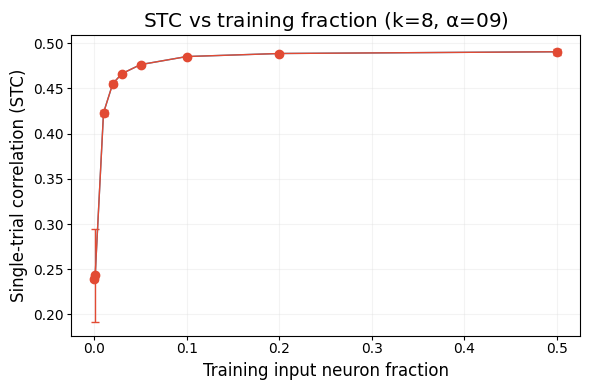

In [19]:
K = 8
ALPHA = "09"
val = True
combine = "total"
plot_stc_vs_train_frac(K=K, ALPHA=ALPHA, combine=combine, val=val)

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16")

def _load_seed_csv(root: Path, K, ALPHA, seed: int, val: bool):
    filename = "stc_val_summary.csv" if val else "stc_test_summary.csv"
    p = root / f"k_{K}" / f"a_{ALPHA}" / f"seed_{seed}" / filename
    if not p.exists():
        return None
    df = pd.read_csv(p)
    for c in ("frac", "mean", "std"):
        df[c] = df[c].astype(float)
    return df

def _collect_seeds(root: Path, K, ALPHA):
    d = root / f"k_{K}" / f"a_{ALPHA}"
    if not d.exists():
        return []
    seeds = []
    for sd in d.glob("seed_*"):
        try:
            seeds.append(int(sd.name.split("_", 1)[1]))
        except Exception:
            pass
    return sorted(seeds)

def _aggregate_over_seeds(dfs, combine="total"):
    # union of fracs across seeds
    all_fracs = sorted(set(np.concatenate([d["frac"].values for d in dfs])))
    xs, ys, es = [], [], []

    for f in all_fracs:
        per_seed_mean, per_seed_std = [], []
        for d in dfs:
            row = d[d["frac"] == f]
            if len(row) == 1:
                per_seed_mean.append(float(row["mean"].iloc[0]))
                per_seed_std.append(float(row["std"].iloc[0]))
        if not per_seed_mean:
            continue

        per_seed_mean = np.asarray(per_seed_mean, float)
        per_seed_std  = np.asarray(per_seed_std, float)

        mean_across = per_seed_mean.mean()
        between_std = per_seed_mean.std(ddof=1) if len(per_seed_mean) > 1 else 0.0
        within_rms  = np.sqrt(np.mean(per_seed_std**2))

        if combine == "between":
            err = between_std
        elif combine == "within":
            err = within_rms
        else:  # "total"
            err = np.sqrt(within_rms**2 + between_std**2)

        xs.append(f); ys.append(mean_across); es.append(err)

    xs = np.asarray(xs, float)
    ys = np.asarray(ys, float)
    es = np.asarray(es, float)

    order = np.argsort(xs)
    return xs[order], ys[order], es[order]

def plot_stc_vs_train_frac_many(
    pairs,                       # list of dicts or tuples: (K, ALPHA, label, seeds(optional))
    root: str | Path = ROOT,
    combine: str = "total",      # "total" | "between" | "within"
    title: str | None = None,
    figsize=(7, 4.5),
    legend=True,
    val=False, 
):
    """
    pairs examples:
      pairs = [
        {"K": 4, "ALPHA": "06",  "label": "k4 a06",  "seeds": [1,2,3]},
        {"K": 8, "ALPHA": "09",  "label": "k8 a09"},                 # seeds auto-discovered
        (12, "1_1", "k12 a1_1", [1,2]),                              # tuple form
      ]
    """
    root = Path(root)
    colors = plt.cm.tab20(np.linspace(0, 1, len(pairs)))
    plt.figure(figsize=figsize)
    ax = plt.gca()

    for i, item in enumerate(pairs):
        if isinstance(item, dict):
            K = item["K"]
            ALPHA = item["ALPHA"]
            label = item.get("label", f"K={K}, A={ALPHA}")
            seeds = item.get("seeds", None)
        else:
            # tuple: (K, ALPHA, label, seeds?)
            K, ALPHA = item[0], item[1]
            label = item[2] if len(item) > 2 else f"K={K}, A={ALPHA}"
            seeds = item[3] if len(item) > 3 else None

        if seeds is None:
            seeds = _collect_seeds(root, K, ALPHA)

        dfs = [_load_seed_csv(root, K, ALPHA, s, val) for s in seeds]
        dfs = [d for d in dfs if d is not None]
        if not dfs:
            print(f"[warn] no CSVs for {label} (K={K}, ALPHA={ALPHA}). Skipping.")
            continue

        x, y, e = _aggregate_over_seeds(dfs, combine=combine)
        ax.errorbar(x, y, yerr=e, marker="o", linewidth=1, capsize=3, label=label, color=colors[i])

    ax.set_xlabel("Training input neuron fraction")
    ax.set_ylabel("Single-trial correlation (STC)")
    ax.set_title(title or "STC vs training fraction")
    ax.grid(True, alpha=0.3)
    if legend:
        ax.legend()
    plt.tight_layout()
    plt.show()


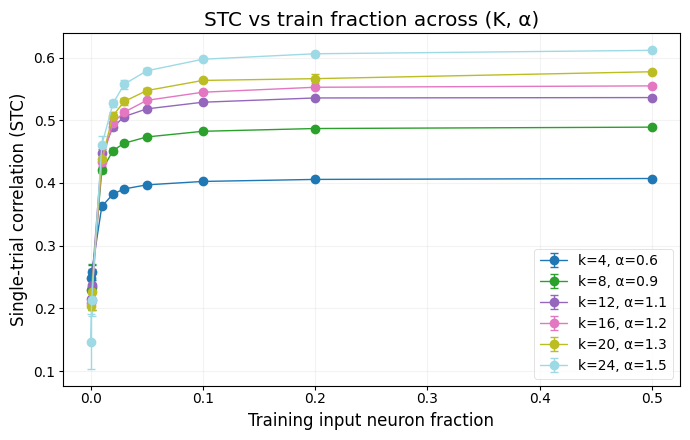

In [13]:
# ---- example usage ----
pairs = [
    {"K": 4,  "ALPHA": "06",  "label": "k=4, α=0.6"},
    {"K": 8,  "ALPHA": "09",  "label": "k=8, α=0.9"},
    {"K": 12, "ALPHA": "1_1", "label": "k=12, α=1.1"},
    {"K": 16, "ALPHA": "1_2", "label": "k=16, α=1.2"},
    {"K": 20, "ALPHA": "1_3", "label": "k=20, α=1.3"},
    {"K": 24, "ALPHA": "1_5", "label": "k=24, α=1.5"},
]
val = False

plot_stc_vs_train_frac_many(pairs, combine="total", title="STC vs train fraction across (K, α)", val=val)

In [15]:
val=True

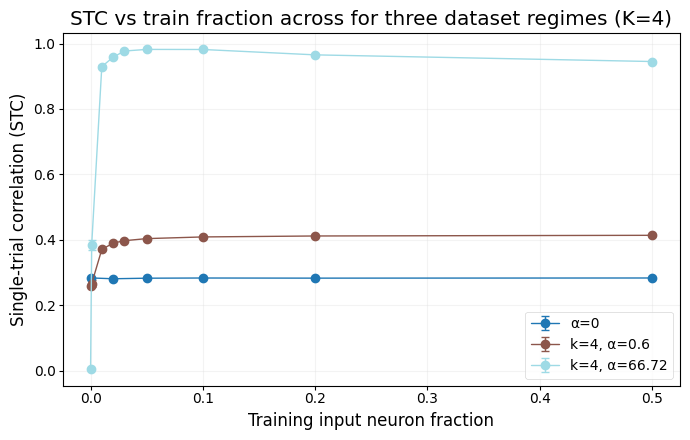

In [16]:
k=4
ALPHA="06"
a=0.6
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

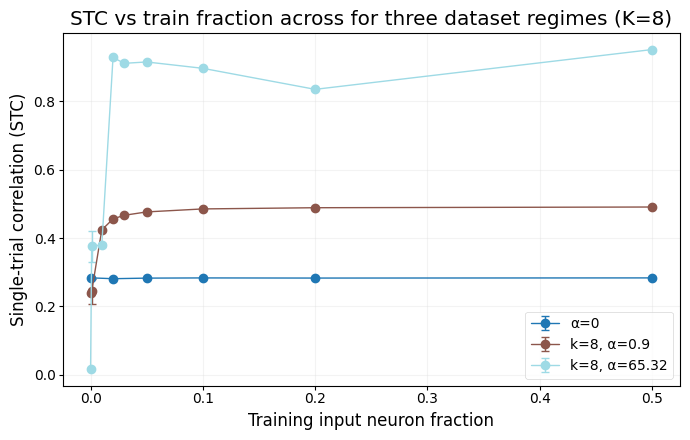

In [17]:
# ---- example usage ----
k=8
ALPHA="09"
a=0.9
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

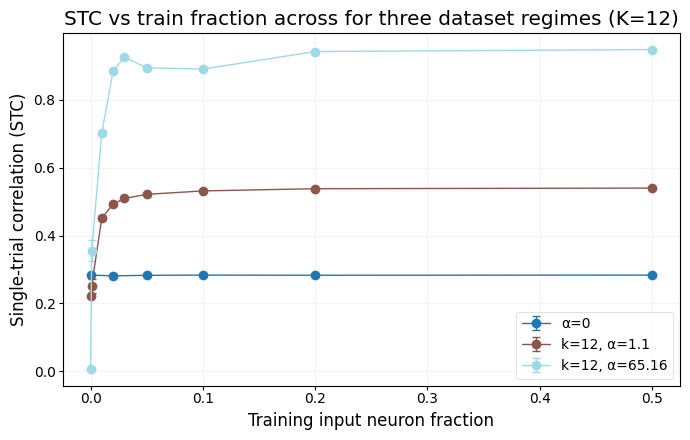

In [18]:
# ---- example usage ----
k=12
ALPHA="1_1"
a=1.1
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

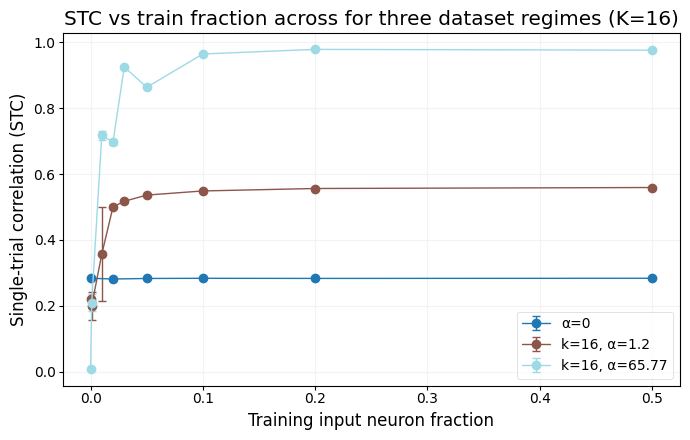

In [19]:
k=16
ALPHA="1_2"
a=1.2
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

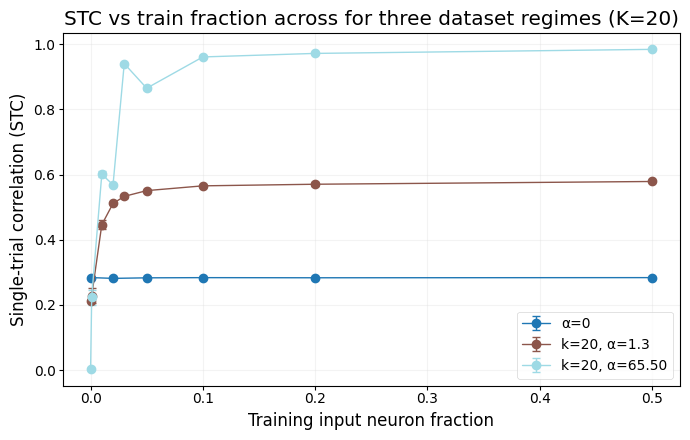

In [20]:
k=20
ALPHA="1_3"
a=1.3
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

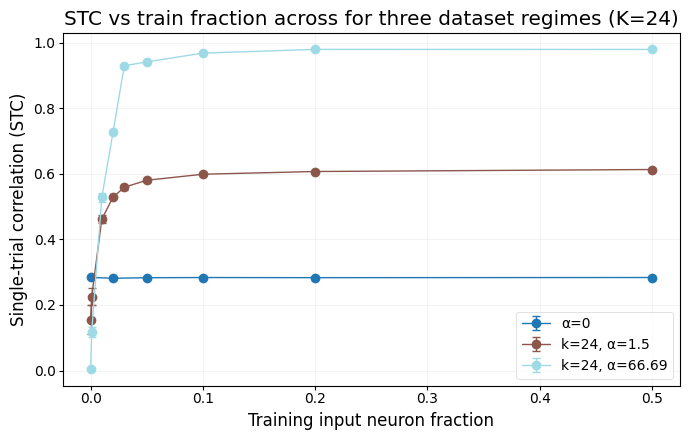

In [21]:
k=24
ALPHA="1_5"
a=1.5
pairs = [
    {"K": 4,  "ALPHA": "0",  "label": "α=0"},
    {"K": k,  "ALPHA": ALPHA,  "label": f"k={k}, α={a}"},
    {"K": k,  "ALPHA": "max", "label": f"k={k}, α={np.load(f'/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy'):.2f}",}
]

plot_stc_vs_train_frac_many(pairs, combine="total", title=f"STC vs train fraction across for three dataset regimes (K={k})", val=val)

# Plot corr vs test time fraction for a fixed model

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16")

def _collect_seeds(root: Path, K, ALPHA):
    d = root / f"k_{K}" / f"a_{ALPHA}"
    if not d.exists():
        return []
    seeds = []
    for sd in d.glob("seed_*"):
        try:
            seeds.append(int(sd.name.split("_", 1)[1]))
        except Exception:
            pass
    return sorted(seeds)

def _load_seed_csv(root: Path, K, ALPHA, seed: int, train_frac_key: str, val: bool):
    fn = "stc_val_per_model_summary.csv" if val else "stc_test_per_model_summary.csv"
    run_dir = (
        root / f"k_{K}" / f"a_{ALPHA}" / f"seed_{seed}"
        / f"k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{train_frac_key}_s_{seed}"
    )
    p = run_dir / fn
    if not p.exists():
        return None
    df = pd.read_csv(p)
    for c in ("frac", "mean", "std"):
        df[c] = df[c].astype(float)
    return df

def _aggregate_over_seeds(dfs, combine="total"):
    all_fracs = sorted(set(np.concatenate([d["frac"].values for d in dfs])))
    xs, ys, es = [], [], []
    for f in all_fracs:
        ms, ss = [], []
        for d in dfs:
            row = d[d["frac"] == f]
            if len(row) == 1:
                ms.append(float(row["mean"].iloc[0]))
                ss.append(float(row["std"].iloc[0]))
        if not ms:
            continue
        ms = np.asarray(ms, float)
        ss = np.asarray(ss, float)

        mean_across = ms.mean()
        between_std = ms.std(ddof=1) if len(ms) > 1 else 0.0
        within_rms  = np.sqrt(np.mean(ss**2))

        if combine == "between":
            err = between_std
        elif combine == "within":
            err = within_rms
        else:
            err = np.sqrt(within_rms**2 + between_std**2)

        xs.append(f); ys.append(mean_across); es.append(err)

    xs = np.asarray(xs, float)
    ys = np.asarray(ys, float)
    es = np.asarray(es, float)
    order = np.argsort(xs)
    return xs[order], ys[order], es[order]

def plot_inspection_curves_for_one_dataset(K, ALPHA, train_fracs, val=False, combine="total", title=None):
    colors = plt.cm.tab20(np.linspace(0, 1, len(train_fracs)))
    plt.figure(figsize=(9, 5))
    ax = plt.gca()

    seeds = _collect_seeds(ROOT, K, ALPHA)

    for i, tf in enumerate(train_fracs):
        train_thr = _parse_frac_key(tf)  # your existing parser: "50"->0.5, "001"->0.001, etc.

        dfs = []
        for s in seeds:
            df = _load_seed_csv(ROOT, K, ALPHA, s, tf, val)
            if df is not None:
                dfs.append(df)

        if not dfs:
            print(f"[warn] missing CSVs for train_frac={tf} (K={K}, ALPHA={ALPHA})")
            continue

        xs, ys, es = _aggregate_over_seeds(dfs, combine=combine)

        # dashed full curve
        ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3,
                    linestyle="--", label=f"{train_thr:g}", color=colors[i])

        # solid overlay for eval fractions <= training fraction
        solid_mask = xs <= train_thr
        if solid_mask.any():
            ax.plot(xs[solid_mask], ys[solid_mask], linewidth=1.5, linestyle="-", label="_nolegend_", color=colors[i])
    # ax.set_xscale("symlog", linthresh=0.1, linscale=1)
    ax.set_xlabel("Evaluation input neuron fraction")
    ax.set_ylabel("Single-trial correlation (STC)")
    ax.set_title(title or f"Test performance across input neuron fractions (K={K}, α={parse_alpha(ALPHA)})")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Training input fraction", ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.5), loc='center left')
    plt.tight_layout()
    plt.show()

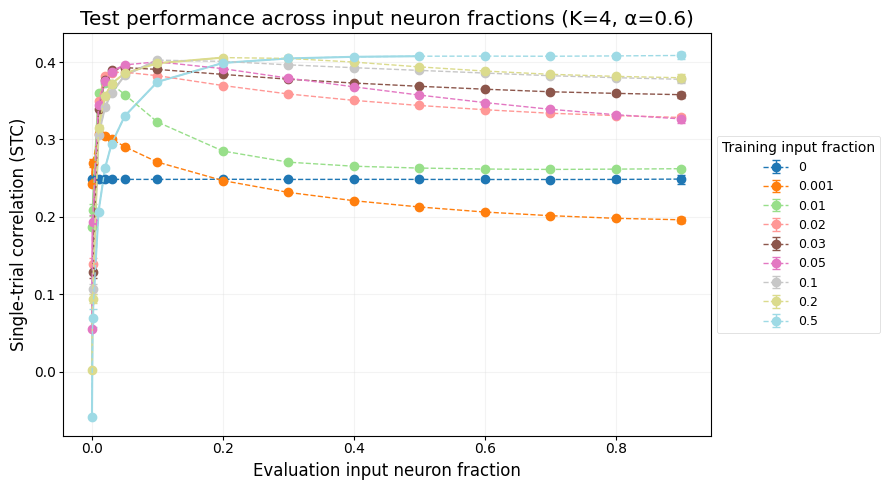

In [40]:
K = 4
ALPHA = "06"
plot_inspection_curves_for_one_dataset(
    K=K,
    ALPHA=ALPHA,
    train_fracs=["00","001","01","02","03","05","10","20","50"],
    val=False,
    combine="total",
    title=None,
)

In [42]:
def plot_inspection_curves_for_one_dataset(K, ALPHA, train_fracs, val=False, combine="total", title=None):
    colors = plt.cm.tab20(np.linspace(0, 1, len(train_fracs)))

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(11, 5), sharey=True,
        gridspec_kw={"width_ratios": [1.2, 1.8]}
    )

    seeds = _collect_seeds(ROOT, K, ALPHA)

    # define the split
    left_max = 0.06
    left_ticks = [0.0, 0.01, 0.02, 0.03, 0.05]
    right_ticks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    for i, tf in enumerate(train_fracs):
        train_thr = _parse_frac_key(tf)

        dfs = []
        for s in seeds:
            df = _load_seed_csv(ROOT, K, ALPHA, s, tf, val)
            if df is not None:
                dfs.append(df)

        if not dfs:
            print(f"[warn] missing CSVs for train_frac={tf} (K={K}, ALPHA={ALPHA})")
            continue

        xs, ys, es = _aggregate_over_seeds(dfs, combine=combine)

        # plot on both axes (they'll be clipped by xlim)
        for ax in (ax1, ax2):
            ax.errorbar(xs, ys, yerr=es, marker="o", linewidth=1, capsize=3,
                        linestyle="--", label=f"{train_thr:g}", color=colors[i])

            solid_mask = xs <= train_thr
            if solid_mask.any():
                ax.plot(xs[solid_mask], ys[solid_mask], linewidth=1.5,
                        linestyle="-", label="_nolegend_", color=colors[i])

    # after creating ax1, ax2
    d = 0.015  # size of diagonal marks
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
    ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

    # axis limits
    ax1.set_xlim(-0.005, left_max)
    ax2.set_xlim(left_max, 0.95)
    # ax1.set_xscale('log')
    
    # ticks (explicit, no weird autoscaling)
    ax1.set_xticks(left_ticks)
    ax1.set_xticklabels([str(t) for t in left_ticks])

    ax2.set_xticks(right_ticks)
    ax2.set_xticklabels([str(t) for t in right_ticks])

    # labels + styling
    ax1.set_xlabel("Input Fraction (Small)")
    ax2.set_xlabel("Input Fraction (Large)")
    ax1.set_ylabel("Correlation")

    fig.suptitle(title or f"Performance Across Input Neuron Fractions (K={K}, α={parse_alpha(ALPHA)})")

    for ax in (ax1, ax2):
        ax.grid(True, alpha=0.3)

    # legend once (on the right)
    ax2.legend(title="Training Input Fraction", ncol=1, fontsize=9,
              bbox_to_anchor=(1.02, 0.5), loc="center left")

    plt.tight_layout()
    plt.show()

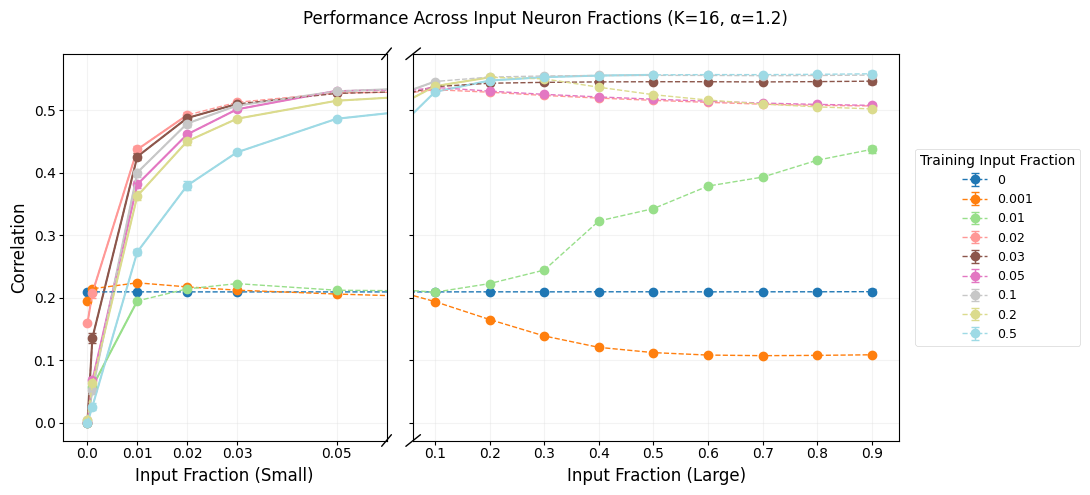

In [53]:
K = 16
ALPHA = "1_2"
plot_inspection_curves_for_one_dataset(
    K=K,
    ALPHA=ALPHA,
    train_fracs=["00","001","01","02","03","05","10","20","50"],
    val=False,
    combine="total",
    title=None,
)

# Plot corr vs k

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



ROOT = Path("/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16")

def load_seed_csv(K, ALPHA, seed, val):
    filename = "stc_val_summary.csv" if val else "stc_test_summary.csv"
    p = ROOT / f"k_{K}" / f"a_{ALPHA}" / f"seed_{seed}" / filename
    if not p.exists():
        return None
    df = pd.read_csv(p)
    # expected columns: frac, mean, std
    df["frac"] = df["frac"].astype(float)
    df["mean"] = df["mean"].astype(float)
    df["std"]  = df["std"].astype(float)
    return df.set_index("frac")

def collect_seeds_for_model(K, ALPHA):
    model_dir = ROOT / f"k_{K}" / f"a_{ALPHA}"
    if not model_dir.exists():
        return []
    seeds = []
    for d in model_dir.glob("seed_*"):
        try:
            seeds.append(int(d.name.split("_", 1)[1]))
        except Exception:
            pass
    return sorted(seeds)

def plot_corr_k(K_list, ALPHA_list, val):

    # ---- gather: for each frac, build y(K) with error bars ----
    # total_std = sqrt( RMS(within-seed std)^2 + between-seed std^2 )
    results = {f: {"K": [], "mean": [], "std": []} for f in fracs}

    for K, ALPHA in zip(K_list, ALPHA_list):
        seeds = collect_seeds_for_model(K, ALPHA)
        dfs = [load_seed_csv(K, ALPHA, s, val) for s in seeds]
        dfs = [d for d in dfs if d is not None]
        if not dfs:
            print(f"[warn] missing CSVs for K={K}, ALPHA={ALPHA}")
            continue

        for f in fracs:
            per_seed_mean, per_seed_std = [], []
            for df in dfs:
                if f in df.index:
                    per_seed_mean.append(df.loc[f, "mean"])
                    per_seed_std.append(df.loc[f, "std"])
            if not per_seed_mean:
                continue

            per_seed_mean = np.asarray(per_seed_mean, float)
            per_seed_std  = np.asarray(per_seed_std, float)

            mean_across = per_seed_mean.mean()
            between_std = per_seed_mean.std(ddof=1) if len(per_seed_mean) > 1 else 0.0
            within_rms  = np.sqrt(np.mean(per_seed_std**2))
            total_std   = np.sqrt(within_rms**2 + between_std**2)

            results[f]["K"].append(K)
            results[f]["mean"].append(mean_across)
            results[f]["std"].append(total_std)

    # ---- plot ----
    colors = plt.cm.tab20(np.linspace(0, 1, len(fracs)))
    plt.figure(figsize=(9, 5))
    ax = plt.gca()

    for i, f in enumerate(fracs):
        Ks = np.asarray(results[f]["K"], float)
        ys = np.asarray(results[f]["mean"], float)
        es = np.asarray(results[f]["std"], float)
        if Ks.size == 0:
            continue
        order = np.argsort(Ks)
        Ks, ys, es = Ks[order], ys[order], es[order]

        ax.errorbar(Ks, ys, yerr=es, marker="o", linewidth=1, capsize=3, label=f"{f:g}", color=colors[i])
        ax.plot(Ks, ys, linewidth=1, color=colors[i])

    ax.set_xlabel("K")
    ax.set_ylabel("Single-trial correlation (STC)")
    ax.set_title("STC vs K")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Training input fraction", ncol=1, fontsize=9, bbox_to_anchor=(1.0, 0.5), loc='center left')
    plt.tight_layout()
    plt.show()

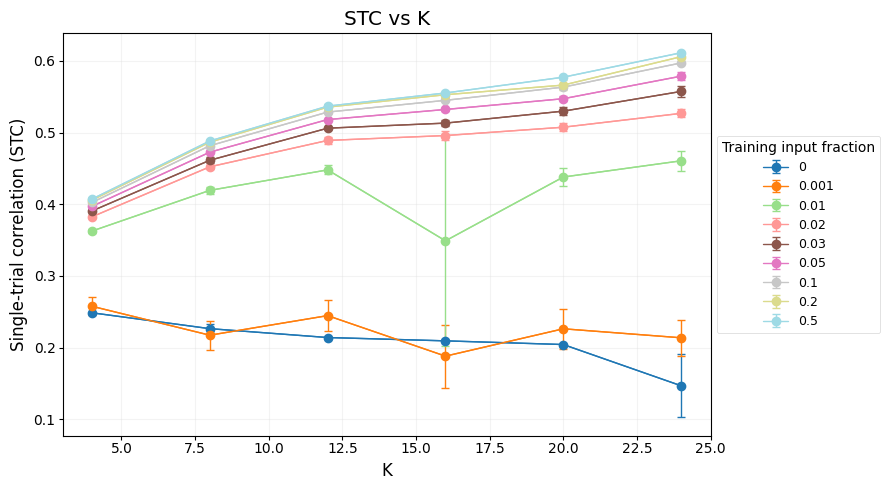

In [36]:
# ---- config ----
K_list     = [4, 8, 12, 16, 20, 24]
ALPHA_list = ["06", "09", "1_1", "1_2", "1_3", "1_5"]#["09","09","09","09","09","09"]#
fracs      = [0.00, 0.001, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.50]  # already floats in CSV
val = False

plot_corr_k(K_list, ALPHA_list, val)

# DRAFT

In [ ]:
stc_means_k8_a_m, stc_std_k8_a_m = evaluate_over_fractions(K=8, ALPHA="max", SEED=1)

In [ ]:
stc_means_k4_a_0, stc_std_k4_a_0 = evaluate_over_fractions(K=4, ALPHA="0", FRAC_INPUT_MODEL=frac, SEED=1)

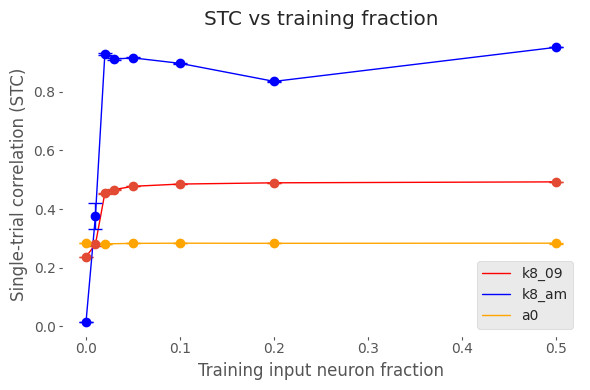

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert dicts -> sorted arrays
fracs = np.array([_parse_frac_key(k) for k in stc_means.keys()], dtype=float)
means = np.array([stc_means[k] for k in stc_means.keys()], dtype=float)
stds  = np.array([stc_std.get(k, 0.0) for k in stc_means.keys()], dtype=float)

order = np.argsort(fracs)
fracs, means, stds = fracs[order], means[order], stds[order]

# If your keys are percentages like "05" meaning 0.05:
# comment this in/out depending on your convention
fracs_plot = fracs / 100.0 if np.max(fracs) > 1.0 else fracs

means_k8_am = np.array([stc_means_k8_a_m[k] for k in stc_means_k8_a_m.keys()], dtype=float)
stds_k8_am  = np.array([stc_std_k8_a_m.get(k, 0.0) for k in stc_std_k8_a_m.keys()], dtype=float)

order = np.argsort(fracs)
means_k8_am, stds_k8_am =  means_k8_am[order], stds_k8_am[order]

fracs_a0 = np.array([_parse_frac_key(k) for k in stc_means_k4_a_0.keys()], dtype=float)
means_k4_a0 = np.array([stc_means_k4_a_0[k] for k in stc_means_k4_a_0.keys()], dtype=float)
stds_k4_a0  = np.array([stc_std_k4_a_0.get(k, 0.0) for k in stc_std_k4_a_0.keys()], dtype=float)


order = np.argsort(fracs_a0)
fracs_a0, means_k4_a0, stds_k4_a0 = fracs_a0[order], means_k4_a0[order], stds_k4_a0[order]
fracs_plot_a0 = fracs_a0 / 100.0 if np.max(fracs_a0) > 1.0 else fracs_a0

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor("white")

plt.errorbar(fracs_plot, means, yerr=stds, fmt='o', capsize=5, linewidth=1)
plt.plot(fracs_plot, means, linewidth=1, c='r', label='k8_09')  # connecting line
plt.errorbar(fracs_plot, means_k8_am, yerr=stds_k8_am, fmt='o', capsize=5, linewidth=1, c='b')
plt.plot(fracs_plot, means_k8_am, linewidth=1, c='b', label='k8_am')  # connecting line
plt.errorbar(fracs_plot_a0, means_k4_a0, yerr=stds_k4_a0, fmt='o', capsize=5, linewidth=1, c='orange')
plt.plot(fracs_plot_a0, means_k4_a0, linewidth=1, c='orange', label='a0')  # connecting line

plt.xlabel("Training input neuron fraction")
plt.ylabel("Single-trial correlation (STC)")
plt.title("STC vs training fraction")
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()

In [120]:
def evaluate_over_sel_fractions(sel_frac, K, ALPHA, FRAC_INPUT_MODEL, SEED):
    STC_means = {}
    STC_std = {}
    for s_frac in sel_frac:
        # load model
        out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"
        parser = argparse.ArgumentParser()
        parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium")
        parser.add_argument("--output_dir", type=str, required=True)
        parser.add_argument("--batch_size", type=int, default=30)
        parser.add_argument("--device", type=str, default="cuda")

        args = parser.parse_args([
            "--output_dir", f"{out_dir}",
        ])
        if not os.path.isdir(args.output_dir):
            raise FileNotFoundError(f"Cannot find {args.output_dir}.")

        utils.get_device(args)
        utils.set_random_seed(1234)

        utils.load_args(args)

        train_ds, val_ds, test_ds = data.get_training_ds(
            args,
            data_dir=args.dataset,
            mouse_ids=args.mouse_ids,
            batch_size=args.batch_size,
            device=args.device,
        )

        model = Model(args, ds=val_ds)
        model.eval()

        scheduler = Scheduler(args, model=model, save_optimizer=False)
        scheduler.restore(force=True)
        scaler = GradScaler(enabled=args.amp)

        # evaluate 
        mouse_results = evaluate_model_sel_frac(
            ds=val_ds,
            model=model,
            device=args.device,
            sel_frac = s_frac,
            verbose=True,
        )
        clear_gpu_memory()
        # torch.empty_cache()
        if s_frac == 0.0:
            STC_means[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation']
            STC_std[s_frac] = 0.0
        else:
            STC_means[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_mean']
            STC_std[s_frac] = mouse_results[f"k_{K}_a_{ALPHA}_b1e7_poisson"]['metrics/single_trial_correlation_std']

    return STC_means, STC_std

In [121]:
sel_frac = [0., 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
STC_means_k8_09_m_0_50, STC_std_k8_09_m_0_50 = evaluate_over_sel_fractions(sel_frac, K=8, ALPHA="09", FRAC_INPUT_MODEL="20", SEED=1)

/mnt/vast-nhr/home/azhar.akhmetova/u12008/neuro-transformer/src/v1t/utils/scheduler.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename, map_loc

image shape (1, 144, 256)
num_output_neurons {'k_8_a_09_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 170 (correlation: 0.4904).

Fraction of input neurons: 0.2
N neurons: 7334


Mouse k_8_a_09_b1e7_poisson: 100%|██████████| 84/84 [00:03<00:00, 23.55it/s]


GPU memory allocated: 0.0 GB
GPU memory reserved:  0.0 GB
image shape (1, 144, 256)
num_output_neurons {'k_8_a_09_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 170 (correlation: 0.4904).

Fraction of input neurons: 0.2
N neurons: 7334
Iteration 1: Using 366 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 1/10: 100%|██████████| 84/84 [00:03<00:00, 27.25it/s]


...

Iteration 9: Using 6600 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 9/10: 100%|██████████| 84/84 [00:07<00:00, 10.69it/s]


Iteration 10: Using 6600 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 10/10: 100%|██████████| 84/84 [00:07<00:00, 10.72it/s]


GPU memory allocated: 0.0 GB
GPU memory reserved:  0.0 GB


In [125]:
def plot_sel_frac_curve(stc_means, stc_std, train_frac, title=None):
    # sort by x
    xs = np.array(sorted(stc_means.keys()), dtype=float)
    ys = np.array([stc_means[x] for x in xs], dtype=float)
    es = np.array([stc_std.get(x, 0.0) for x in xs], dtype=float)

    plt.figure(figsize=(6,4), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    # error bars + markers
    plt.errorbar(xs, ys, yerr=es, fmt='o', capsize=3, linewidth=1)

    # split indices
    solid = xs <= train_frac
    dashed = xs >= train_frac

    # line segments
    if solid.any():
        plt.plot(xs[solid], ys[solid], linewidth=1.5, linestyle='-')
    if dashed.any():
        # connect from last solid point to first dashed point so curve is continuous
        # if solid.any():
        #     x0, y0 = xs[solid][-1], ys[solid][-1]
        #     x1, y1 = xs[dashed][0], ys[dashed][0]
        #     plt.plot([x0, x1], [y0, y1], linewidth=1.5, linestyle='--')
        plt.plot(xs[dashed], ys[dashed], linewidth=1.5, linestyle='--')

    # vertical marker at training fraction (optional but helpful)
    plt.axvline(train_frac, linewidth=1, alpha=0.25)

    plt.xlabel("Evaluation input neuron fraction (sel_frac)")
    plt.ylabel("Single-trial correlation (STC)")
    plt.title(title or f"STC vs sel_frac (solid ≤ train_frac={train_frac})")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


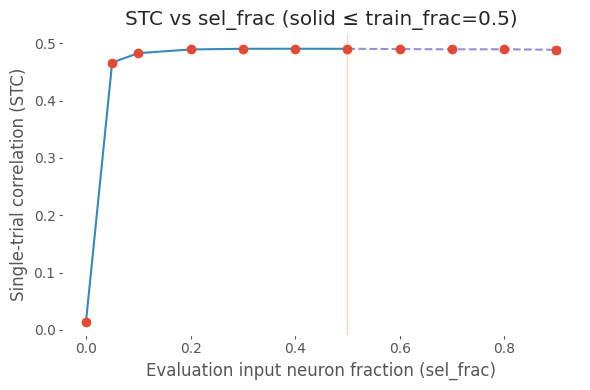

In [126]:
plot_sel_frac_curve(STC_means_k8_09_m_0_50, STC_std_k8_09_m_0_50, train_frac=0.5)

# Evaluate one model 

In [ ]:
K = 8
ALPHA = "09"
FRAC_INPUT_MODEL = "50"
SEED = 1

In [71]:
out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx04_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"

In [63]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/u12008/neuro-transformer/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=10)
parser.add_argument("--device", type=str, default="cuda")

args = parser.parse_args([
    "--output_dir", f"{out_dir}",
])

In [64]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

scaler = GradScaler(enabled=args.amp)

image shape (1, 144, 256)
num_output_neurons {'k_8_a_09_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: []

Loaded checkpoint from epoch 226 (correlation: 0.4942).



In [65]:
@torch.no_grad()
def compute_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):
    """Metrics to compute as part of training and validation step"""
    msse = losses.msse(y_true=y_true, y_pred=y_pred)
    poisson_loss = losses.poisson_loss(y_true=y_true, y_pred=y_pred)
    correlation = losses.correlation(y1=y_pred, y2=y_true, dim=0)
    correlation = torch.mean(correlation)
    bits_per_spike = losses.bits_per_spike(y_true=y_true, y_pred=y_pred)
    return {
        "metrics/msse": msse,
        "metrics/poisson_loss": poisson_loss,
        "metrics/single_trial_correlation": correlation,
        "metrics/bits_per_spike": bits_per_spike,
    }

def evaluate_model(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    verbose: bool = True,
):
    model.to(device).eval()
    results = {}
    for mouse_id, ds in ds.items():
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        print(f"Fraction of input neurons: {frac_input_neurons}")
        N = ds.dataset.num_neurons
        print(f"N neurons: {N}")
        
        all_results = []  # Store results from each iteration

        if frac_input_neurons == 0.:
            targets, predictions = [], [] 
            for batch in tqdm(ds, desc=f"Mouse {mouse_id}", disable=not verbose):
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=None,
                            query_neuron_ids=torch.arange(N).to(device),
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                    targets.append(y_true.detach().cpu())
                    predictions.append(y_pred.detach().cpu())
                    del y_true, y_pred
                        
            targets = torch.vstack(targets).cpu()
            predictions = torch.vstack(predictions).cpu()
            
            # Compute metrics for this iteration
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions)
            
            del targets, predictions
            torch.cuda.empty_cache()

        else:
            for i in range(10):  # repeat evaluation n times with different input/query split
                perm = torch.randperm(N, device=device)
                K = int(frac_input_neurons * N)
                input_neuron_ids = perm[:K].to(device)
                print(f"Iteration {i+1}: Using {len(input_neuron_ids)} input neurons.")
                query_neuron_ids = perm[K:].to(device)
                targets, predictions = [], [] 
                
                for batch in tqdm(ds, desc=f"Mouse {mouse_id} - Iter {i+1}/25", disable=not verbose):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                                images=batch["image"].to(device),
                                responses=batch["response"].to(device),
                                neuron_coords=batch["neuron_coordinates"].to(device),
                                input_neuron_ids=input_neuron_ids,
                                query_neuron_ids=query_neuron_ids,
                                mouse_id=mouse_id,
                                behaviors=batch["behavior"].to(device),
                                pupil_centers=batch["pupil_center"].to(device),
                            )
                        targets.append(y_true.detach().cpu())
                        predictions.append(y_pred.detach().cpu())
                        del y_true, y_pred
                        
                targets = torch.vstack(targets).cpu()
                predictions = torch.vstack(predictions).cpu()
                
                # Compute metrics for this iteration
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions)
                all_results.append(iteration_results)
                
                del targets, predictions

            # Aggregate results across all iterations
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key].item() if hasattr(result[key], 'item') else result[key] 
                        for result in all_results]
                mouse_results[f"{key}_mean"] = np.mean(values)
                mouse_results[f"{key}_std"] = np.std(values)
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results

        torch.cuda.empty_cache()

    return results

In [66]:
mouse_results_50 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

Fraction of input neurons: 0.5
N neurons: 7334
Iteration 1: Using 3667 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 1/25: 100%|██████████| 252/252 [00:04<00:00, 50.66it/s]


Iteration 2: Using 3667 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 2/25: 100%|██████████| 252/252 [00:04<00:00, 50.60it/s]


Iteration 3: Using 3667 input neurons.


...

Mouse k_8_a_09_b1e7_poisson - Iter 8/25: 100%|██████████| 252/252 [00:04<00:00, 51.10it/s]


Iteration 9: Using 3667 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 9/25: 100%|██████████| 252/252 [00:04<00:00, 50.89it/s]


Iteration 10: Using 3667 input neurons.


Mouse k_8_a_09_b1e7_poisson - Iter 10/25: 100%|██████████| 252/252 [00:04<00:00, 51.43it/s]


In [67]:
mouse_results_50

{'k_8_a_09_b1e7_poisson': {'metrics/msse_mean': np.float64(7170082.45),
  'metrics/msse_std': np.float64(23258.7263187927),
  'metrics/msse_all': [7171868.0,
   7135161.5,
   7162105.5,
   7178660.0,
   7170949.0,
   7161346.0,
   7208440.0,
   7204258.0,
   7133802.5,
   7174234.0],
  'metrics/poisson_loss_mean': np.float64(nan),
  'metrics/poisson_loss_std': np.float64(nan),
  'metrics/poisson_loss_all': [nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   5914810.0],
  'metrics/single_trial_correlation_mean': np.float64(0.4925473064184189),
  'metrics/single_trial_correlation_std': np.float64(0.001052350800855623),
  'metrics/single_trial_correlation_all': [0.4912102520465851,
   0.49276599287986755,
   0.493070125579834,
   0.4941462576389313,
   0.49167099595069885,
   0.4917847514152527,
   0.49166083335876465,
   0.49179714918136597,
   0.4944349229335785,
   0.4929317831993103],
  'metrics/bits_per_spike_mean': np.float64(nan),
  'metrics/bits_per_spike_std'

In [80]:
mouse_results_50['k_8_a_09_b1e7_poisson']['metrics/single_trial_correlation_mean']

np.float64(0.4925473064184189)

In [ ]:
mouse_results_001 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_005 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_01 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_02 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_03 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_04 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_05 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_10 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_20 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_25 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [18]:
mouse_results_50 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

Fraction of input neurons: 0.5
N neurons: 7334
Iteration 1: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 1/25:   0%|          | 0/503 [00:00<?, ?it/s]

Mouse k_4_a_03_xyz_b1e7_poisson - Iter 1/25: 100%|██████████| 503/503 [00:10<00:00, 48.99it/s]


Iteration 2: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 2/25: 100%|██████████| 503/503 [00:10<00:00, 49.98it/s]


...

Mouse k_4_a_03_xyz_b1e7_poisson - Iter 23/25: 100%|██████████| 503/503 [00:11<00:00, 42.24it/s]


Iteration 24: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 24/25: 100%|██████████| 503/503 [00:09<00:00, 50.93it/s]


Iteration 25: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 25/25: 100%|██████████| 503/503 [00:11<00:00, 43.81it/s]


In [55]:
mouse_results_0

{'k_4_a_03_xyz_b1e7_poisson': {'metrics/msse': tensor(17476054.),
  'metrics/poisson_loss': tensor(nan),
  'metrics/single_trial_correlation': tensor(0.2564),
  'metrics/bits_per_spike': tensor(nan)}}

In [98]:
mouse_results_001['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.258051335811615,
 0.25801998376846313,
 0.2579527199268341,
 0.25796568393707275,
 0.2580922544002533,
 0.2580069899559021,
 0.258113294839859,
 0.2580700218677521,
 0.2580031752586365,
 0.25801804661750793,
 0.2579568326473236,
 0.2580304741859436,
 0.2580198347568512,
 0.25797343254089355,
 0.2580455541610718,
 0.2580353915691376,
 0.2580430209636688,
 0.2579975426197052,
 0.2580791115760803,
 0.25809961557388306,
 0.25807181000709534,
 0.25800853967666626,
 0.258048415184021,
 0.2579880654811859,
 0.25800296664237976]

In [116]:
mouse_results_005['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3568817675113678,
 0.3548751473426819,
 0.35691165924072266,
 0.35603001713752747,
 0.3577277660369873,
 0.3544096350669861,
 0.3514642119407654,
 0.3521657884120941,
 0.3615914583206177,
 0.35479483008384705,
 0.3585887849330902,
 0.35818079113960266,
 0.35257571935653687,
 0.35778579115867615,
 0.36230936646461487,
 0.3528114855289459,
 0.3585079312324524,
 0.3586668074131012,
 0.3580417037010193,
 0.35591909289360046,
 0.36109527945518494,
 0.3476230502128601,
 0.35850149393081665,
 0.36029213666915894,
 0.3536182940006256]

In [74]:
mouse_results_01['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.25923797488212585,
 0.25917503237724304,
 0.2593182623386383,
 0.2592555284500122,
 0.2591196298599243,
 0.2593919336795807,
 0.25933587551116943,
 0.25937598943710327,
 0.259007066488266,
 0.2591848373413086,
 0.2591002583503723,
 0.25936928391456604,
 0.25910475850105286,
 0.25917550921440125,
 0.2594023644924164,
 0.2590111494064331,
 0.2596144676208496,
 0.2591942548751831,
 0.25925663113594055,
 0.2593444585800171,
 0.25951141119003296,
 0.25918048620224,
 0.2593400478363037,
 0.2595295011997223,
 0.2592930495738983]

In [106]:
mouse_results_02['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.24138952791690826,
 0.24248968064785004,
 0.24188759922981262,
 0.2432107925415039,
 0.24146805703639984,
 0.24345450103282928,
 0.2398439347743988,
 0.24213562905788422,
 0.2428814321756363,
 0.23824428021907806,
 0.24079261720180511,
 0.23930811882019043,
 0.23802606761455536,
 0.24180838465690613,
 0.24098941683769226,
 0.24210397899150848,
 0.24370989203453064,
 0.24022187292575836,
 0.24355703592300415,
 0.24090401828289032,
 0.24184119701385498,
 0.2397439330816269,
 0.24115608632564545,
 0.2432534098625183,
 0.24316036701202393]

In [111]:
mouse_results_03['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3904918134212494,
 0.39082109928131104,
 0.3916454613208771,
 0.39071500301361084,
 0.3909330368041992,
 0.3904931843280792,
 0.3909105658531189,
 0.3908270001411438,
 0.3917263448238373,
 0.3910253345966339,
 0.39054563641548157,
 0.3908163905143738,
 0.39036107063293457,
 0.3904869258403778,
 0.3907501995563507,
 0.390420526266098,
 0.39133840799331665,
 0.39084392786026,
 0.3908572793006897,
 0.3909772038459778,
 0.3909936249256134,
 0.39064881205558777,
 0.3913569450378418,
 0.39128202199935913,
 0.39080896973609924]

In [126]:
mouse_results_04['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.2584635019302368,
 0.25796079635620117,
 0.2583557069301605,
 0.2581055462360382,
 0.2581554055213928,
 0.2584272623062134,
 0.2584546208381653,
 0.25843921303749084,
 0.25796788930892944,
 0.2580074965953827,
 0.2582769989967346,
 0.2583388388156891,
 0.25819697976112366,
 0.25838175415992737,
 0.25833389163017273,
 0.25793543457984924,
 0.25923848152160645,
 0.25832563638687134,
 0.2580029368400574,
 0.2588540315628052,
 0.25861626863479614,
 0.258124977350235,
 0.25892505049705505,
 0.25862932205200195,
 0.25812196731567383]

In [121]:
mouse_results_05['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3984614908695221,
 0.3980090022087097,
 0.3987235724925995,
 0.3982028067111969,
 0.3982856869697571,
 0.3980829417705536,
 0.39849159121513367,
 0.3983011245727539,
 0.39836055040359497,
 0.39815109968185425,
 0.3981981575489044,
 0.3979378640651703,
 0.39798665046691895,
 0.3980126976966858,
 0.3978317379951477,
 0.39791351556777954,
 0.3987949788570404,
 0.3983127772808075,
 0.3982385993003845,
 0.3989439308643341,
 0.3986104428768158,
 0.398027241230011,
 0.39896872639656067,
 0.39854663610458374,
 0.3978584110736847]

In [44]:
mouse_results_10['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.4007522165775299,
 0.4006712734699249,
 0.4007580876350403,
 0.4009142220020294,
 0.40085676312446594,
 0.40037667751312256,
 0.40087011456489563,
 0.40092459321022034,
 0.40066275000572205,
 0.4002196788787842,
 0.4006541967391968,
 0.39972537755966187,
 0.40120387077331543,
 0.4001415967941284,
 0.40055209398269653,
 0.40132850408554077,
 0.40114033222198486,
 0.40071505308151245,
 0.4002808630466461,
 0.4008259177207947,
 0.4010394513607025,
 0.40082430839538574,
 0.4012332856655121,
 0.401387482881546,
 0.4008913040161133]

In [131]:
mouse_results_20['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.40282902121543884,
 0.40260079503059387,
 0.4012669622898102,
 0.4026203155517578,
 0.40229424834251404,
 0.40232202410697937,
 0.4029025435447693,
 0.40110212564468384,
 0.40163570642471313,
 0.4024966359138489,
 0.4022078812122345,
 0.40172407031059265,
 0.4035228490829468,
 0.40157121419906616,
 0.40261971950531006,
 0.4031052887439728,
 0.40225064754486084,
 0.4030740559101105,
 0.4024447202682495,
 0.4026373326778412,
 0.4023851156234741,
 0.40347516536712646,
 0.4029737710952759,
 0.40260860323905945,
 0.40228304266929626]

In [136]:
mouse_results_25['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3981967270374298,
 0.39741265773773193,
 0.39710623025894165,
 0.39774906635284424,
 0.39802736043930054,
 0.39750465750694275,
 0.3986388146877289,
 0.39729562401771545,
 0.3969642221927643,
 0.397491991519928,
 0.39774417877197266,
 0.3970372676849365,
 0.39958861470222473,
 0.3973930776119232,
 0.398682564496994,
 0.39888298511505127,
 0.3976772427558899,
 0.39799949526786804,
 0.3980712592601776,
 0.3984406888484955,
 0.39764559268951416,
 0.399168998003006,
 0.3984704315662384,
 0.3977201282978058,
 0.39759886264801025]

In [19]:
mouse_results_50['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.4005199074745178,
 0.4003540873527527,
 0.40023893117904663,
 0.4025235176086426,
 0.4000215232372284,
 0.3995729088783264,
 0.4007822871208191,
 0.4004792273044586,
 0.402827650308609,
 0.40083613991737366,
 0.39963892102241516,
 0.3994837701320648,
 0.40444567799568176,
 0.39705049991607666,
 0.40099814534187317,
 0.4016836881637573,
 0.4008188545703888,
 0.39949366450309753,
 0.4026883542537689,
 0.40399491786956787,
 0.40088626742362976,
 0.40213775634765625,
 0.4005368649959564,
 0.4004305601119995,
 0.4013611972332001]

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Data extracted from outputs
fractions = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 10, 20, 25, 50]

# Correlation values for each fraction
correlations_data = {
    0: [0.2564], 
    0.01: [0.258051335811615, 0.25801998376846313, 0.2579527199268341, 0.25796568393707275, 0.2580922544002533, 0.2580069899559021, 0.258113294839859, 0.2580700218677521, 0.2580031752586365, 0.25801804661750793, 0.2579568326473236, 0.2580304741859436, 0.2580198347568512, 0.25797343254089355, 0.2580455541610718, 0.2580353915691376, 0.2580430209636688, 0.2579975426197052, 0.2580791115760803, 0.25809961557388306, 0.25807181000709534, 0.25800853967666626, 0.258048415184021, 0.2579880654811859, 0.25800296664237976],
    
    0.05: [0.3568817675113678, 0.3548751473426819, 0.35691165924072266, 0.35603001713752747, 0.3577277660369873, 0.3544096350669861, 0.3514642119407654, 0.3521657884120941, 0.3615914583206177, 0.35479483008384705, 0.3585887849330902, 0.35818079113960266, 0.35257571935653687, 0.35778579115867615, 0.36230936646461487, 0.3528114855289459, 0.3585079312324524, 0.3586668074131012, 0.3580417037010193, 0.35591909289360046, 0.36109527945518494, 0.3476230502128601, 0.35850149393081665, 0.36029213666915894, 0.3536182940006256],
    
    0.1: [0.25923797488212585, 0.25917503237724304, 0.2593182623386383, 0.2592555284500122, 0.2591196298599243, 0.2593919336795807, 0.25933587551116943, 0.25937598943710327, 0.259007066488266, 0.2591848373413086, 0.2591002583503723, 0.25936928391456604, 0.25910475850105286, 0.25917550921440125, 0.2594023644924164, 0.2590111494064331, 0.2596144676208496, 0.2591942548751831, 0.25925663113594055, 0.2593444585800171, 0.25951141119003296, 0.25918048620224, 0.2593400478363037, 0.2595295011997223, 0.2592930495738983],
    
    0.2: [0.24138952791690826, 0.24248968064785004, 0.24188759922981262, 0.2432107925415039, 0.24146805703639984, 0.24345450103282928, 0.2398439347743988, 0.24213562905788422, 0.2428814321756363, 0.23824428021907806, 0.24079261720180511, 0.23930811882019043, 0.23802606761455536, 0.24180838465690613, 0.24098941683769226, 0.24210397899150848, 0.24370989203453064, 0.24022187292575836, 0.24355703592300415, 0.24090401828289032, 0.24184119701385498, 0.2397439330816269, 0.24115608632564545, 0.2432534098625183, 0.24316036701202393],
    
    0.3: [0.3904918134212494, 0.39082109928131104, 0.3916454613208771, 0.39071500301361084, 0.3909330368041992, 0.3904931843280792, 0.3909105658531189, 0.3908270001411438, 0.3917263448238373, 0.3910253345966339, 0.39054563641548157, 0.3908163905143738, 0.39036107063293457, 0.3904869258403778, 0.3907501995563507, 0.390420526266098, 0.39133840799331665, 0.39084392786026, 0.3908572793006897, 0.3909772038459778, 0.3909936249256134, 0.39064881205558777, 0.3913569450378418, 0.39128202199935913, 0.39080896973609924],
    
    0.4: [0.2584635019302368, 0.25796079635620117, 0.2583557069301605, 0.2581055462360382, 0.2581554055213928, 0.2584272623062134, 0.2584546208381653, 0.25843921303749084, 0.25796788930892944, 0.2580074965953827, 0.2582769989967346, 0.2583388388156891, 0.25819697976112366, 0.25838175415992737, 0.25833389163017273, 0.25793543457984924, 0.25923848152160645, 0.25832563638687134, 0.2580029368400574, 0.2588540315628052, 0.25861626863479614, 0.258124977350235, 0.25892505049705505, 0.25862932205200195, 0.25812196731567383],
    
    0.5: [0.3984614908695221, 0.3980090022087097, 0.3987235724925995, 0.3982028067111969, 0.3982856869697571, 0.3980829417705536, 0.39849159121513367, 0.3983011245727539, 0.39836055040359497, 0.39815109968185425, 0.3981981575489044, 0.3979378640651703, 0.39798665046691895, 0.3980126976966858, 0.3978317379951477, 0.39791351556777954, 0.3987949788570404, 0.3983127772808075, 0.3982385993003845, 0.3989439308643341, 0.3986104428768158, 0.398027241230011, 0.39896872639656067, 0.39854663610458374, 0.3978584110736847],
    
    10: [0.4007522165775299, 0.4006712734699249, 0.4007580876350403, 0.4009142220020294, 0.40085676312446594, 0.40037667751312256, 0.40087011456489563, 0.40092459321022034, 0.40066275000572205, 0.4002196788787842, 0.4006541967391968, 0.39972537755966187, 0.40120387077331543, 0.4001415967941284, 0.40055209398269653, 0.40132850408554077, 0.40114033222198486, 0.40071505308151245, 0.4002808630466461, 0.4008259177207947, 0.4010394513607025, 0.40082430839538574, 0.4012332856655121, 0.401387482881546, 0.4008913040161133],
    
    20: [0.40282902121543884, 0.40260079503059387, 0.4012669622898102, 0.4026203155517578, 0.40229424834251404, 0.40232202410697937, 0.4029025435447693, 0.40110212564468384, 0.40163570642471313, 0.4024966359138489, 0.4022078812122345, 0.40172407031059265, 0.4035228490829468, 0.40157121419906616, 0.40261971950531006, 0.4031052887439728, 0.40225064754486084, 0.4030740559101105, 0.4024447202682495, 0.4026373326778412, 0.4023851156234741, 0.40347516536712646, 0.4029737710952759, 0.40260860323905945, 0.40228304266929626],
    
    25: [0.3981967270374298, 0.39741265773773193, 0.39710623025894165, 0.39774906635284424, 0.39802736043930054, 0.39750465750694275, 0.3986388146877289, 0.39729562401771545, 0.3969642221927643, 0.397491991519928, 0.39774417877197266, 0.3970372676849365, 0.39958861470222473, 0.3973930776119232, 0.398682564496994, 0.39888298511505127, 0.3976772427558899, 0.39799949526786804, 0.3980712592601776, 0.3984406888484955, 0.39764559268951416, 0.399168998003006, 0.3984704315662384, 0.3977201282978058, 0.39759886264801025],
    
    50: [0.4005199074745178, 0.4003540873527527, 0.40023893117904663, 0.4025235176086426, 0.4000215232372284, 0.3995729088783264, 0.4007822871208191, 0.4004792273044586, 0.402827650308609, 0.40083613991737366, 0.39963892102241516, 0.3994837701320648, 0.40444567799568176, 0.39705049991607666, 0.40099814534187317, 0.4016836881637573, 0.4008188545703888, 0.39949366450309753, 0.4026883542537689, 0.40399491786956787, 0.40088626742362976, 0.40213775634765625, 0.4005368649959564, 0.4004305601119995, 0.4013611972332001]
}

# Calculate means and standard deviations
means = []
stds = []

for fraction in fractions:
    data = np.array(correlations_data[fraction])
    means.append(np.mean(data))
    stds.append(np.std(data))

means = np.array(means)
stds = np.array(stds)

print("Fraction -> Mean ± Std")
for i, frac in enumerate(fractions):
    print(f"{frac:4.1f}% -> {means[i]:.4f} ± {stds[i]:.4f}")

Fraction -> Mean ± Std
 0.0% -> 0.2564 ± 0.0000
 0.0% -> 0.2580 ± 0.0000
 0.1% -> 0.3565 ± 0.0034
 0.1% -> 0.2593 ± 0.0002
 0.2% -> 0.2415 ± 0.0016
 0.3% -> 0.3909 ± 0.0004
 0.4% -> 0.2583 ± 0.0003
 0.5% -> 0.3983 ± 0.0003
10.0% -> 0.4008 ± 0.0004
20.0% -> 0.4024 ± 0.0006
25.0% -> 0.3979 ± 0.0007
50.0% -> 0.4010 ± 0.0015



Best performance: 0.4024 ± 0.0006 at 20%
Worst performance: 0.2415 ± 0.0016 at 0.2%


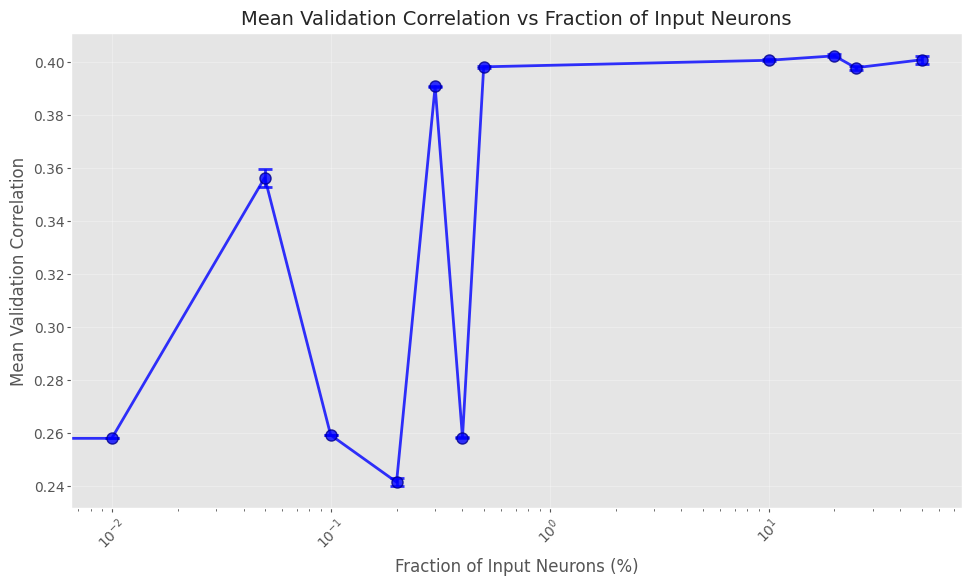

In [61]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.errorbar(fractions, means, yerr=stds, marker='o', linewidth=2, markersize=8, 
             capsize=5, capthick=2, elinewidth=2, markerfacecolor='blue', 
             markeredgecolor='darkblue', color='blue', alpha=0.8)

plt.xlabel('Fraction of Input Neurons (%)', fontsize=12)
plt.ylabel('Mean Validation Correlation', fontsize=12)
plt.title('Mean Validation Correlation vs Fraction of Input Neurons', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Add some formatting
plt.xticks(fractions, [f'{f}%' for f in fractions], rotation=45)
plt.tight_layout()
plt.xscale('log')
# Show statistics
print(f"\nBest performance: {means.max():.4f} ± {stds[np.argmax(means)]:.4f} at {fractions[np.argmax(means)]}%")
print(f"Worst performance: {means.min():.4f} ± {stds[np.argmin(means)]:.4f} at {fractions[np.argmin(means)]}%")

plt.show()

In [62]:
# First, let's clear CUDA memory and check usage
import gc
torch.cuda.empty_cache()
gc.collect()

print("CUDA Memory Usage:")
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

CUDA Memory Usage:
Allocated: 0.01 GB
Reserved: 0.02 GB


In [63]:
@torch.no_grad()
def memory_efficient_evaluate_model(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    verbose: bool = True,
    max_iterations: int = 25,
    clear_cache_every: int = 5,  # Clear cache every N iterations
):
    """Memory-efficient version with aggressive cleanup"""
    
    # Clear memory before starting
    torch.cuda.empty_cache()
    gc.collect()
    
    model.to(device).eval()
    results = {}
    
    for mouse_id, ds in ds.items():
        print(f"\nProcessing mouse: {mouse_id}")
        
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        N = ds.dataset.num_neurons
        print(f"Fraction: {frac_input_neurons}, N neurons: {N}")
        
        if frac_input_neurons == 0.:
            # Single evaluation for fraction 0
            targets, predictions = [], [] 
            
            for batch_idx, batch in enumerate(tqdm(ds, desc=f"Mouse {mouse_id}")):
                # Process in smaller chunks and clear intermediate tensors
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                        images=batch["image"].to(device),
                        responses=batch["response"].to(device),
                        neuron_coords=batch["neuron_coordinates"].to(device),
                        input_neuron_ids=None,
                        query_neuron_ids=torch.arange(N).to(device),
                        mouse_id=mouse_id,
                        behaviors=batch["behavior"].to(device),
                        pupil_centers=batch["pupil_center"].to(device),
                    )
                    
                    # Move to CPU immediately to save GPU memory
                    targets.append(y_true.cpu())
                    predictions.append(y_pred.cpu())
                    
                    # Clear GPU tensors
                    del y_true, y_pred
                    
                    # Periodic cache clearing
                    if batch_idx % clear_cache_every == 0:
                        torch.cuda.empty_cache()
                        
            targets = torch.vstack(targets)
            predictions = torch.vstack(predictions)
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions)
            
            # Clear everything
            del targets, predictions
            torch.cuda.empty_cache()
            gc.collect()

        else:
            # Multiple iterations for non-zero fractions
            all_results = []
            
            for i in range(max_iterations):
                print(f"Iteration {i+1}/{max_iterations}")
                
                # Create new permutation
                perm = torch.randperm(N, device=device)
                K = int(frac_input_neurons * N)
                input_neuron_ids = perm[:K]
                query_neuron_ids = perm[K:]
                
                targets, predictions = [], []
                
                for batch_idx, batch in enumerate(tqdm(ds, desc=f"Iter {i+1}", leave=False)):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=input_neuron_ids,
                            query_neuron_ids=query_neuron_ids,
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                        
                        # Move to CPU immediately
                        targets.append(y_true.cpu())
                        predictions.append(y_pred.cpu())
                        
                        # Clear GPU tensors
                        del y_true, y_pred
                        
                        # Periodic cache clearing
                        if batch_idx % clear_cache_every == 0:
                            torch.cuda.empty_cache()
                
                # Compute metrics for this iteration
                targets = torch.vstack(targets)
                predictions = torch.vstack(predictions)
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions)
                
                # Extract scalar values and store
                scalar_results = {}
                for key, value in iteration_results.items():
                    scalar_results[key] = value.item() if hasattr(value, 'item') else value
                all_results.append(scalar_results)
                
                # Clear iteration data
                del targets, predictions, iteration_results, scalar_results
                del input_neuron_ids, query_neuron_ids, perm
                
                # Aggressive cleanup every few iterations
                if i % clear_cache_every == 0:
                    torch.cuda.empty_cache()
                    gc.collect()
            
            # Aggregate results
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key] for result in all_results]
                mouse_results[f"{key}_mean"] = np.mean(values)
                mouse_results[f"{key}_std"] = np.std(values)
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results
            del all_results

        # Final cleanup for this mouse
        torch.cuda.empty_cache()
        gc.collect()
        
        # Print memory usage
        print(f"Memory after mouse {mouse_id}: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    return results

In [ ]:
def evaluate_all_fractions_safely(model, val_ds, device, fractions_to_test=None):
    """
    Safely evaluate all fractions by setting model attributes and clearing memory between runs
    """
    if fractions_to_test is None:
        fractions_to_test = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 10, 20, 25, 50]
    
    all_results = {}
    
    for fraction in fractions_to_test:
        print(f"\n{'='*50}")
        print(f"EVALUATING FRACTION: {fraction}")
        print(f"{'='*50}")
        
        # Clear everything before each evaluation
        torch.cuda.empty_cache()
        gc.collect()
        
        # Set the fraction on the model
        model.frac_input_neurons = fraction
        
        try:
            # Run evaluation with memory-efficient function
            results = memory_efficient_evaluate_model(
                ds=val_ds,
                model=model,
                device=device,
                verbose=True,
                max_iterations=25 if fraction > 0 else 1,
                clear_cache_every=3  # More frequent clearing
            )
            
            all_results[f"fraction_{fraction}"] = results
            print(f"✓ Successfully completed fraction {fraction}")
            
        except torch.cuda.OutOfMemoryError as e:
            print(f"✗ CUDA OOM for fraction {fraction}: {e}")
            # Emergency cleanup
            torch.cuda.empty_cache()
            gc.collect()
            continue
        except Exception as e:
            print(f"✗ Error for fraction {fraction}: {e}")
            continue
        
        # Always clear after each fraction
        torch.cuda.empty_cache()
        gc.collect()
        
        print(f"Memory after fraction {fraction}: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    
    return all_results

# Example usage (uncomment to run):
# all_fraction_results = evaluate_all_fractions_safely(
#     model=model, 
#     val_ds=val_ds, 
#     device=args.device,
#     fractions_to_test=[0.0, 0.01, 0.05, 0.1]  # Start with a few fractions
# )

In [64]:
# IMMEDIATE FIXES - Run this now to clear memory issues:

print("=== EMERGENCY MEMORY CLEANUP ===")

# 1. Clear all variables that might be holding CUDA tensors
variables_to_clear = [
    'mouse_results_0'
]

for var_name in variables_to_clear:
    if var_name in globals():
        print(f"Clearing {var_name}")
        del globals()[var_name]

# 2. Garbage collection
import gc
gc.collect()

# 3. Clear CUDA cache
torch.cuda.empty_cache()

# 4. Check current memory usage
print(f"\nMemory after cleanup:")
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

# 5. Reset CUDA if needed (uncomment if still having issues)
# torch.cuda.reset_peak_memory_stats()
# torch.cuda.empty_cache()

print("\n=== MEMORY CLEANUP COMPLETE ===")

# 6. Additional recommendations:
print("\nRECOMMENDATIONS:")
print("1. Reduce batch_size in args (try batch_size=1 or 2)")
print("2. Use smaller max_iterations (try 10 instead of 25)") 
print("3. Process one fraction at a time")
print("4. Restart kernel if problems persist")

=== EMERGENCY MEMORY CLEANUP ===
Clearing mouse_results_0

Memory after cleanup:
Allocated: 0.01 GB
Reserved: 0.02 GB

=== MEMORY CLEANUP COMPLETE ===

RECOMMENDATIONS:
1. Reduce batch_size in args (try batch_size=1 or 2)
2. Use smaller max_iterations (try 10 instead of 25)
3. Process one fraction at a time
4. Restart kernel if problems persist
